(48, 2)

/var/folders/hc/0hj953jj47b5k0cwy0lp1vqr0000gn/T/ipykernel_37325/840260955.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


,Dates,Prices
43,2024-05-31,11.4
44,2024-06-30,11.5
45,2024-07-31,11.6
46,2024-08-31,11.5
47,2024-09-30,11.8


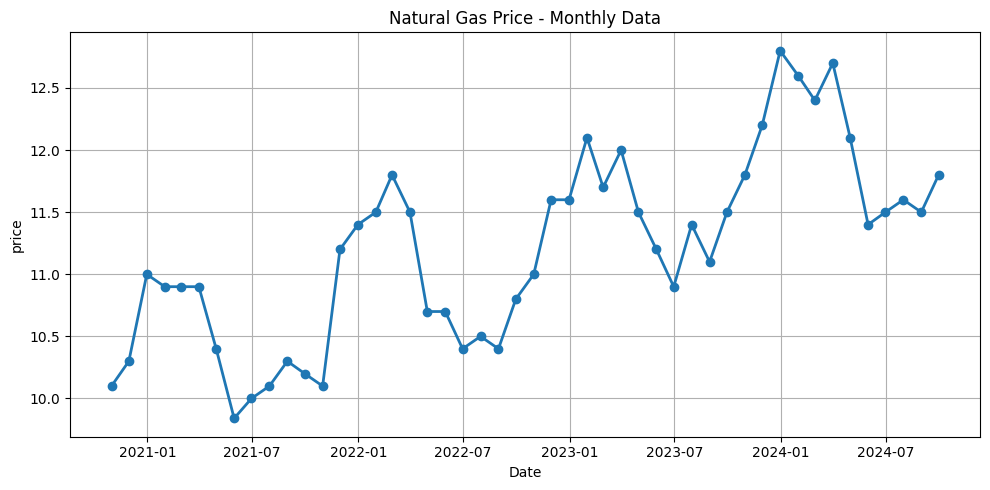

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

display(df.shape)
df = pd.read_csv('Nat_Gas.csv')

# parsing dates properly
df['Dates'] = pd.to_datetime(df['Dates'])

# sort by dates 
df = df.sort_values('Dates').reset_index(drop = True)

display(df.head())
display(df.tail())

plt.figure(figsize = (10,5))
plt.plot(df['Dates'], df['Prices'], marker = 'o', linewidth = 2)
plt.title('Natural Gas Price - Monthly Data')
plt.xlabel('Date')
plt.ylabel('price')
plt.grid(True)
plt.tight_layout()
plt.savefig('Natural Gas Prices - Monthly Data_png', dpi = 150)
plt.show()

tells us that the prices peaks in the winter.

(buy in summer, sell in winter)

now we need to build the pricing function using cubicspline.

CubicSpline = gives the smooth curve through the data points. Given any dates, it returns the estimated price on that curve. For data data beyond the data range, it extrapolates following the same trend

In [48]:
# Converting dates to numbers (Days since first date) - Spline needs numbers not dates.
df['days'] = (df['Dates'] - df['Dates'].min()).dt.days        # .dt.days just pulls out the numeric day count

# fit cubic spline through all data points
spline = CubicSpline(df['days'], df['Prices'])

# Function that takes any date string and returns estimated price
def get_price(date_str):
    date = pd.to_datetime(date_str)     # convert input string into datetime
    days = (date - df['Dates'].min()).days      # convert date into "days since first dataset date"
    price = spline(days)
    return round(float(price), 2)

# test it on few dates
print("Oct 31 2020 (first data point):", get_price('2020-10-31'))
print("Jun 15 2022 (between data points):", get_price('2022-06-15'))
print("Jan 15 2025 (future estimate):", get_price('2025-01-15'))
print("Jun 30 2025 (future estimate):", get_price('2025-06-30'))

Oct 31 2020 (first data point): 10.1
Jun 15 2022 (between data points): 10.55
Jan 15 2025 (future estimate): 26.7
Jun 30 2025 (future estimate): 151.92


future estimates are way off! This is the problem with CubeSpline extrapolation beyond the data range it goes wild

better approach:

date in range: use cubespline extrapolation

dates beyond range: calculate the average price for that month across all years and use that

In [67]:
# add month column to capture seasonal pattern
df['month'] = df['Dates'].dt.month

# average price per month across all years
monthly_avg = df.groupby('month')['Prices'].mean()
print("monthly averages: ")
print(monthly_avg)

def get_prices(date_str):
    date = pd.to_datetime(date_str)
    days = (date - df['Dates'].min()).days
    max_days = (df['Dates'].max() - df['Dates'].min()).days

    if days <= max_days:
        price = spline(days)

    else:
        price = monthly_avg[date.month]     # date.month gives month from the date 

    return round(float(price), 2)

print("\nOct 31 2020 (first data point):", get_prices('2020-10-31'))
print("Jun 15 2022 (between data points):", get_prices('2022-06-15'))
print("Jan 15 2025 (future estimate):", get_prices('2025-01-15'))
print("Jun 30 2025 (future estimate):", get_prices('2025-06-30'))

monthly averages: 
month
1     11.775
2     11.700
3     11.775
4     11.175
5     10.785
6     10.700
7     10.900
8     10.825
9     11.075
10    10.750
11    11.325
12    11.700
Name: Prices, dtype: float64

Oct 31 2020 (first data point): 10.1
Jun 15 2022 (between data points): 10.55
Jan 15 2025 (future estimate): 11.78
Jun 30 2025 (future estimate): 10.7


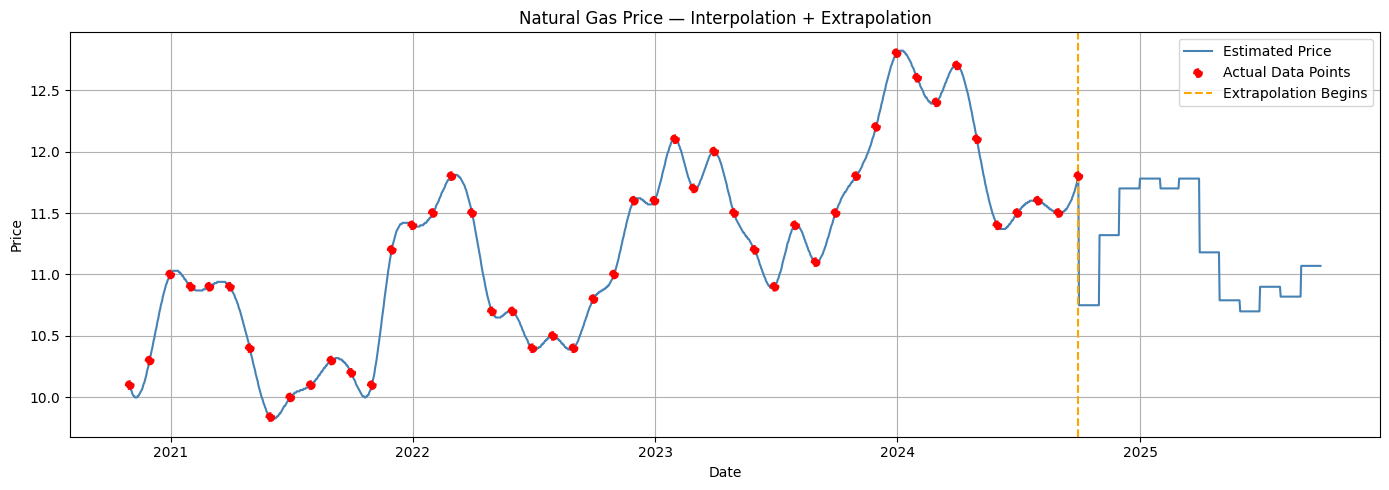

In [82]:
# generating daily dates from start of data to 1 year into the future
date_range = pd.date_range(start = df['Dates'].min(), end = '2025-09-30', freq = 'D')       # D = daily

# get price for every day
estimated_prices = []

for d in date_range:
    price = get_prices(str(d.date()))
    estimated_prices.append(price)

plt.figure(figsize = (14,5))
# plot estimated curve
plt.plot(date_range, estimated_prices, color = 'steelblue', linewidth = 1.5, label = 'Estimated Price')
# plot original data points on top
plt.scatter(df['Dates'], df['Prices'], color = 'red', linestyle = '--', linewidth = 1.5, zorder = 30, s = 30, label = 'Actual Data Points')

# mark when extrapolation begins
plt.axvline(x = df['Dates'].max(), color = 'orange', linestyle = '--', linewidth = 1.5, label = 'Extrapolation Begins')

plt.title('Natural Gas Price — Interpolation + Extrapolation')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('gas_price_curve.png', dpi=150)
plt.show()

In [85]:
# Final clean function for submission

def estimated_gas_price(date_str):
    """
    Takes a date string (YYYY-MM-DD) and returns estimated natural gas price.
    Uses cubic spline interpolation for historical dates.
    Uses seasonal monthly averages for future dates.
    """
    date = pd.to_datetime(date_str)
    days = (date - df['Dates'].min()).days
    max_days = (df['Dates'].max() - df['Dates'].min()).days

    if days <= max_days:
        price = spline(days)
    else:
        price = monthly_avg[date.month]

    return round(float(price), 2)

test_dates = ['2021-06-15', '2022-11-30', '2023-03-10', '2025-01-15', '2025-07-04']
for d in test_dates:
    print(f"{d} → ${estimated_gas_price(d)}")

2021-06-15 → $9.87
2022-11-30 → $11.6
2023-03-10 → $11.76
2025-01-15 → $11.78
2025-07-04 → $10.9
